In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("imakash3011/customer-personality-analysis")

print("Path to dataset files:", path)

Path to dataset files: /Users/poltava/.cache/kagglehub/datasets/imakash3011/customer-personality-analysis/versions/1


In [6]:
#Загружаем датасет
df = pd.read_csv(f"{path}/marketing_campaign.csv", sep='\t')

In [7]:
#Выводим первые 5 наблюдений
df.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [19]:
#Смотрим основные описательные статистики в т.ч. типы фич и их масштаб

df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


###  Предварительный вывод по датасету
- Year_Birth - тип данных дата
- KidHome - категория
- Teenhome - категория
- AcceptedCmp№ - категории
- Response - категория


In [20]:
def find_nan(df):
    #  Проверяем на кол-во пропусков и их долю в данных

    # Количество пропусков по столбцам
    missing_counts = df.isna().sum()
    print(f'\nКоличество пропусков по признакам:')
    print('-' * 40)
    print(missing_counts[missing_counts > 0] if missing_counts.any() else 'Пропусков нет!')
    print('-' * 40)

    #Процент пропусков
    if missing_counts.any():
        missing_percent = (missing_counts[missing_counts > 0] / df.shape[0] * 100).round(2)
        print(f'\nПроцент пропусков по признакам:')
        print('-' * 40)
        for col, percent in missing_percent.items():
            print(f'{col}: {percent}%')
        print('-' * 40)
        
    # Сводная статистика
        total_missing = missing_counts.sum()
        total_cells = df.shape[0] * df.shape[1]
        overall_missing_percent = (total_missing / total_cells * 100).round(2)
        
        print(f'\nСводная статистика:')
        print(f'Всего пропущенных значений: {total_missing}')
        print(f'Общий процент пропусков: {overall_missing_percent}%')
        print(f'Кол-во признаков с пропусками: {len(missing_percent)} из {df.shape[1]}')
    else:
        print('\nВ данных нет пропущенных значений!')
find_nan(df)


Количество пропусков по признакам:
----------------------------------------
Пропусков нет!
----------------------------------------

В данных нет пропущенных значений!


Объем пропусков мал и лежит в фиче Income. Можем пренебречь данными наблюдениями и убрать пропуски.

In [21]:
#Удаляем пропуски

df.dropna(inplace=True)

In [22]:
#Проверка на дубли в данных

if df.duplicated().sum() == 0:
    print("Дубликатов нет")
else:
    print(f"Кол-во дублей - {df.duplicated().sum()}")

Дубликатов нет


Проверяем, что пропуски были успешно убраны с данных

In [23]:
find_nan(df)


Количество пропусков по признакам:
----------------------------------------
Пропусков нет!
----------------------------------------

В данных нет пропущенных значений!


# EDA

In [24]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


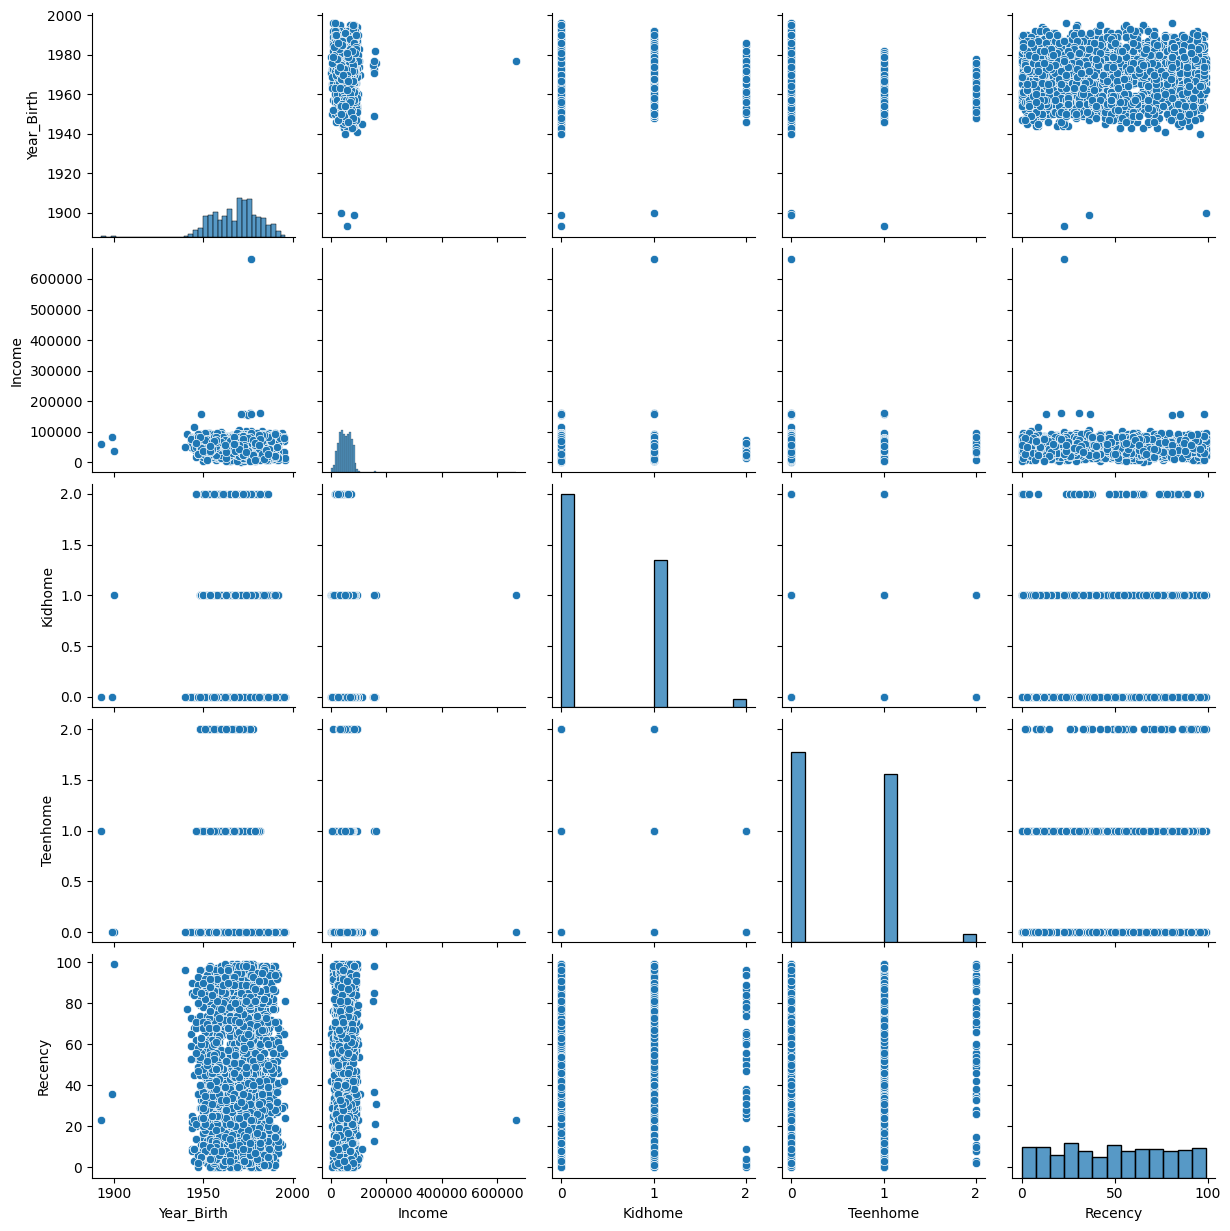

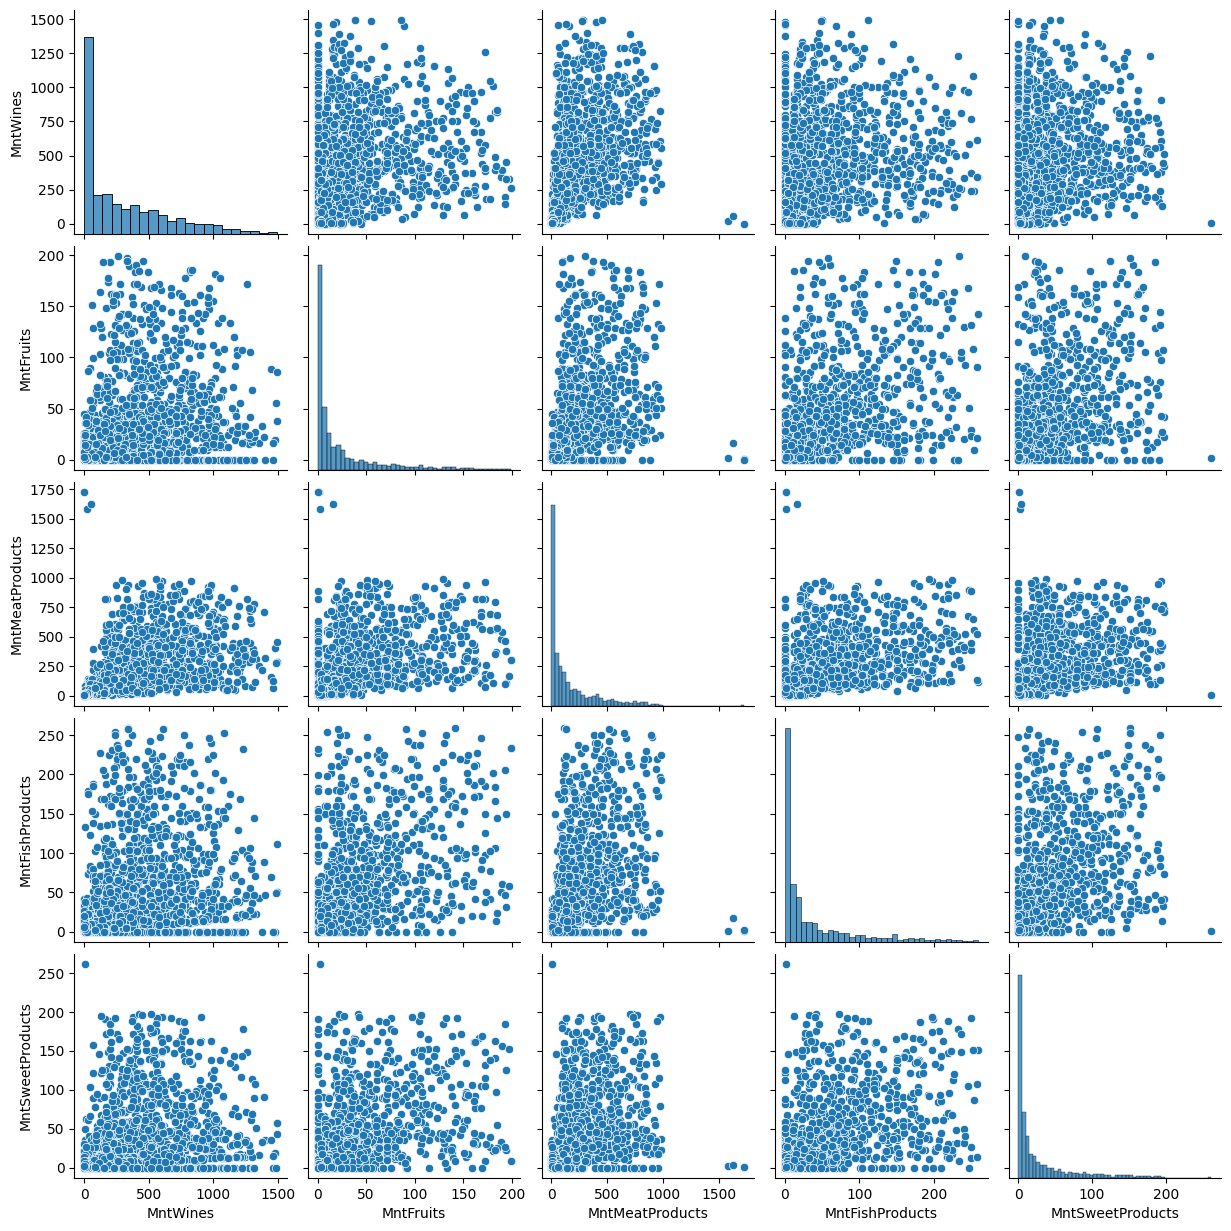

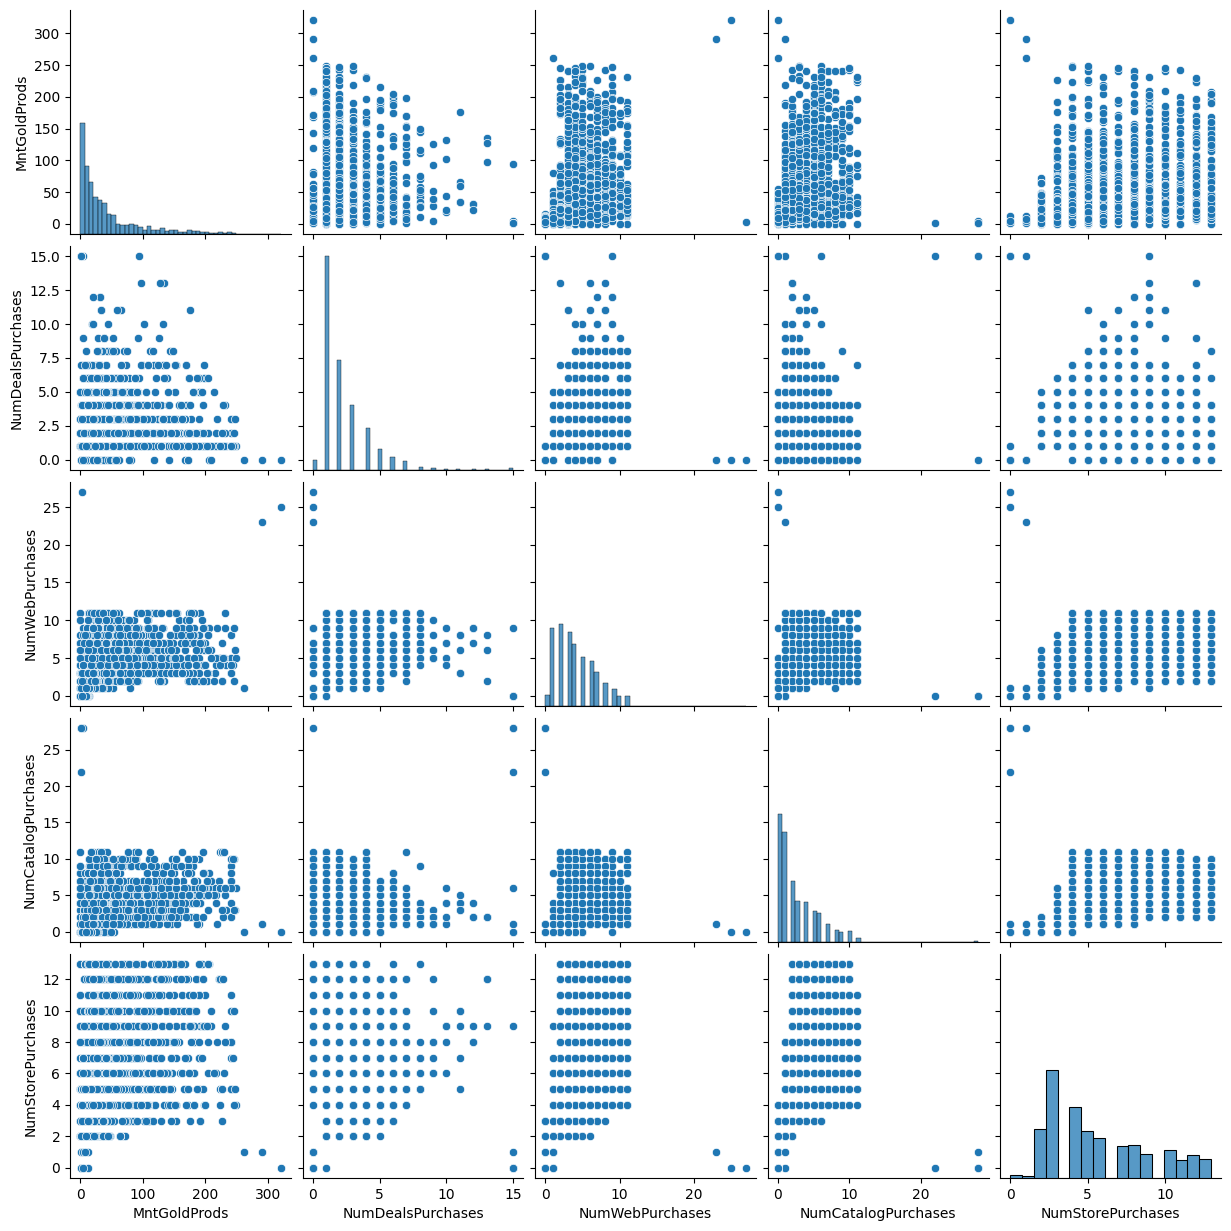

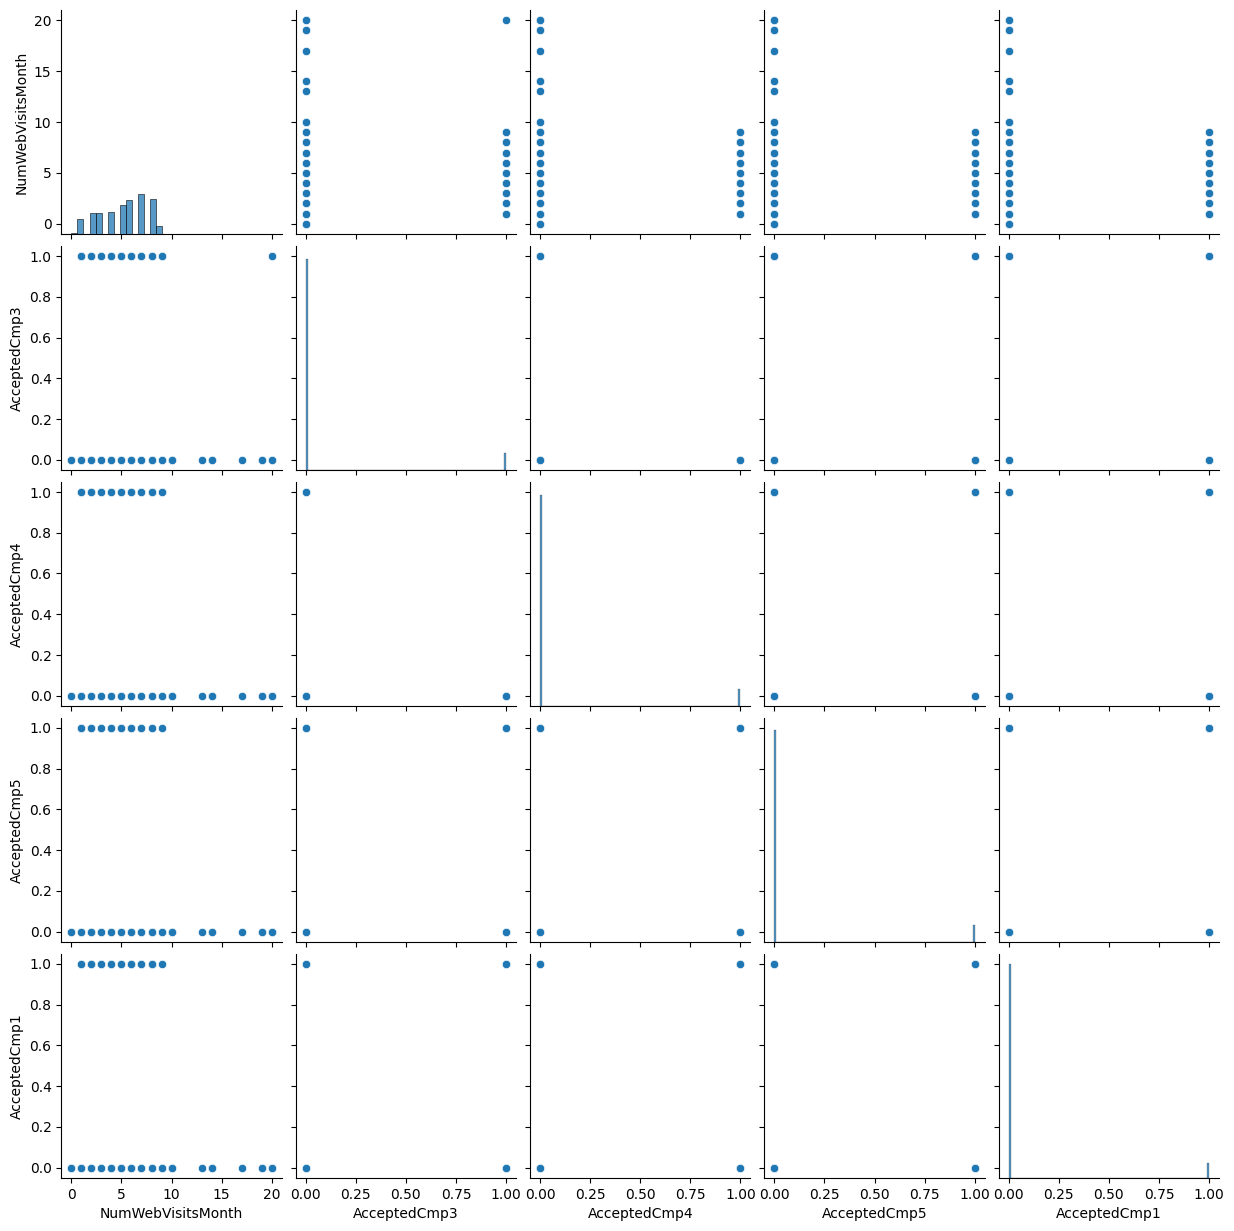

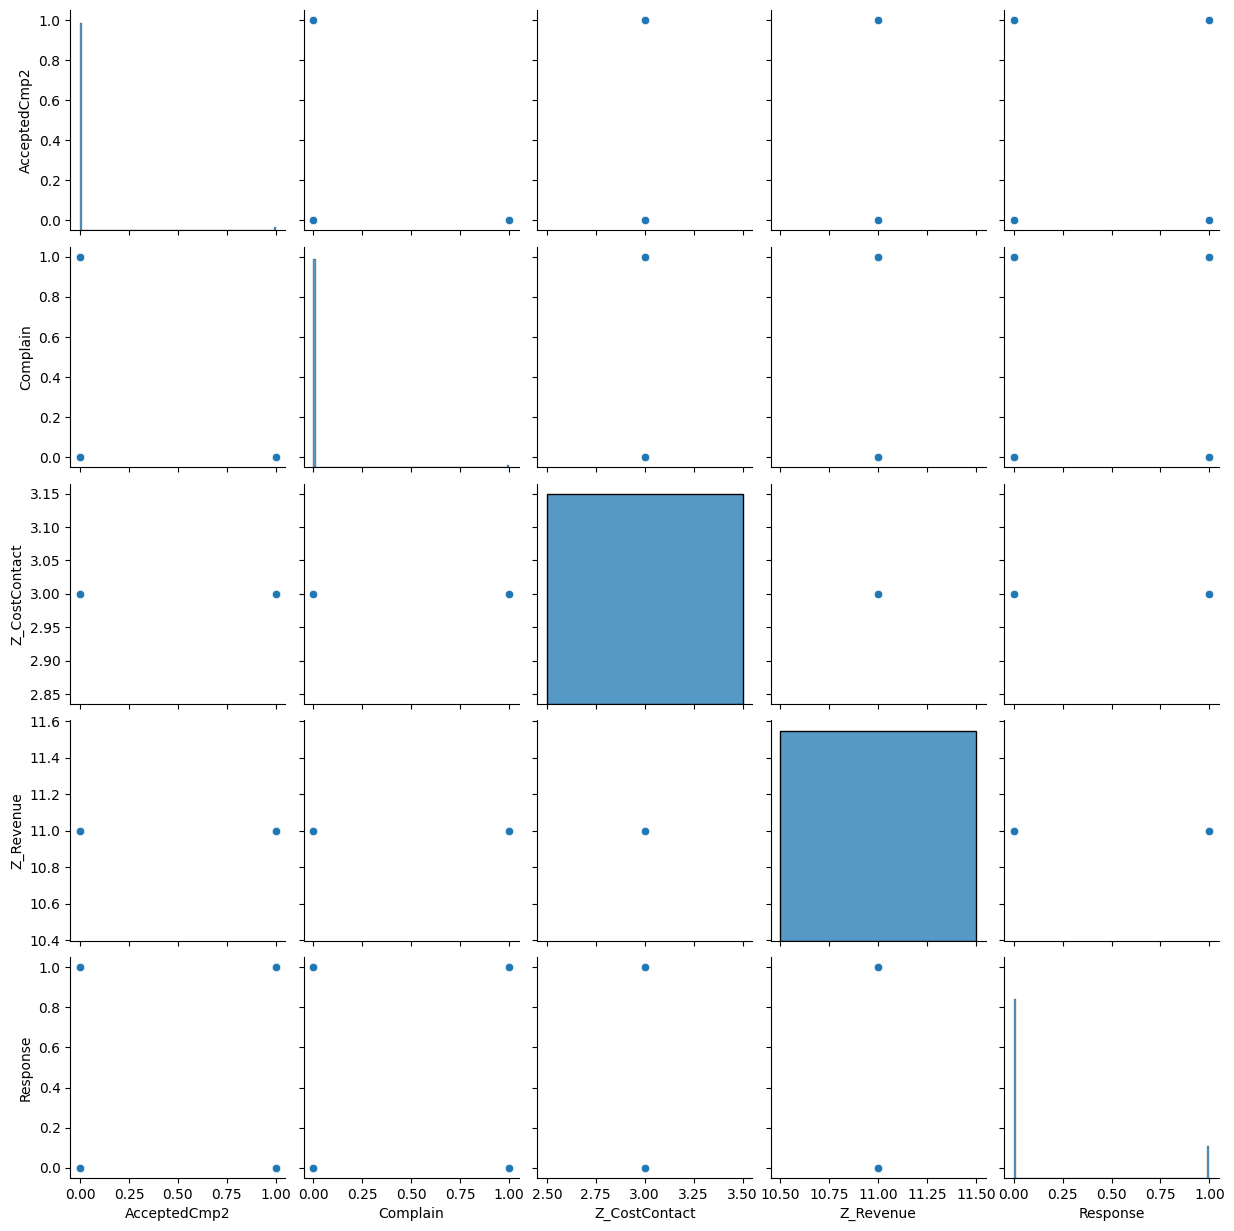

In [25]:
num_columns = df.select_dtypes(np.number).columns.to_list()
for i in range(1,len(num_columns),5):
    sns.pairplot(df[num_columns].iloc[:,i:i+5])

Анализ графика показал, что категориальных фичей много: Response, KidHome, Teenhome, Income, AcceptedCmp1-5

Проверяем схему данных на наличие типов которые можно перекодировать в более оптимальный.

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2216 non-null   int64  
 1   Year_Birth           2216 non-null   int64  
 2   Education            2216 non-null   object 
 3   Marital_Status       2216 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2216 non-null   int64  
 6   Teenhome             2216 non-null   int64  
 7   Dt_Customer          2216 non-null   object 
 8   Recency              2216 non-null   int64  
 9   MntWines             2216 non-null   int64  
 10  MntFruits            2216 non-null   int64  
 11  MntMeatProducts      2216 non-null   int64  
 12  MntFishProducts      2216 non-null   int64  
 13  MntSweetProducts     2216 non-null   int64  
 14  MntGoldProds         2216 non-null   int64  
 15  NumDealsPurchases    2216 non-null   int64 

Преобразуем типы категориальных фичей -> category

In [61]:
catogory_features = ['Response', 'Kidhome', 'Teenhome', 'Income', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
df[catogory_features] = df[catogory_features].astype("category")

In [62]:
#Добавляем фичи с типом ОBJECT к нашим категориальным фичам
catogory_features.extend(df.select_dtypes('object').columns.to_list())

In [63]:
#Формируем числовые признаки
numerical_features = ([col for col in df.columns.to_list() if col not in catogory_features and col not in ['Year_Birth', 'ID']])

## Создадим базовую модель K-means c препроцессором. Кластеризация чувствительна к масштабу

In [72]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline

In [66]:
preprocessor = ColumnTransformer(transformers=[
        ('cat', OneHotEncoder(drop='first'), catogory_features),
        ('num', StandardScaler(), numerical_features)
    ])

In [59]:
print(numerical_features.extend(catogory_features))

None


In [68]:
X = df.drop(labels=['Year_Birth', 'ID'], axis=1)

In [70]:
preprocessor.fit(X)  # обучение на данных
X_transformed = preprocessor.transform(X)

Text(0, 0.5, 'WCSS')

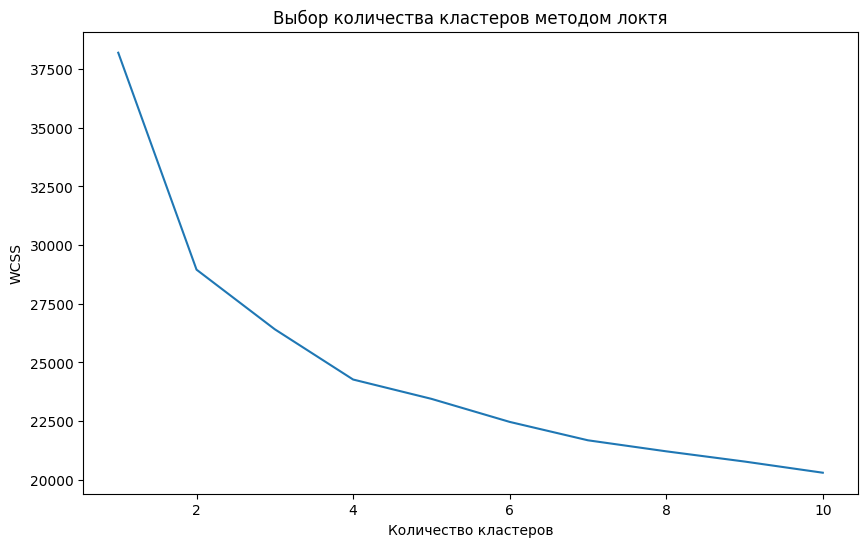

In [71]:
# создадим пустой список для записи показателя WCSS (ошибки)
wcss = []
 
# воспользуемся новой для нас функцией range(), она возвращает последовательность чисел
# в данном случае числа от 1 до 10
for i in range(1, 11):
    
    # настроим параметры модели (подробнее об этом расскажу чуть дальше)
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 42)
 
    # обучим модель на данных с разным количеством кластеров
    kmeans.fit(X_transformed)
 
    # для каждого кластера рассчитаем ошибку (атрибут inertia_) и поместим в список
    wcss.append(kmeans.inertia_)
 
# зададим размер график
plt.figure(figsize = (10,6))
# передадим функции plot() последовательность кластеров и ошибку WCSS
plt.plot(range(1, 11), wcss)
# и добавим подписи
plt.title('Выбор количества кластеров методом локтя')
plt.xlabel('Количество кластеров')
plt.ylabel('WCSS')

In [139]:
# заново обучим модель с 4 кластерами
kmeans = KMeans(n_clusters = 4, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 42)


In [140]:
# обучение и прогноз в данном случае можно сделать одним методом .fit_predict()
y_pred = kmeans.fit_predict(X_transformed)

In [141]:
cluster_labels = kmeans.labels_
cluster_labels


array([3, 1, 0, ..., 0, 0, 1], shape=(2216,), dtype=int32)

In [142]:
from sklearn.metrics import silhouette_score

In [143]:
silhouette_avg = silhouette_score(X_transformed, cluster_labels)
print(f"Средний коэффициент силуэта: {silhouette_avg:.3f}")

Средний коэффициент силуэта: 0.190


In [144]:
num_labels = cluster_labels.tolist()

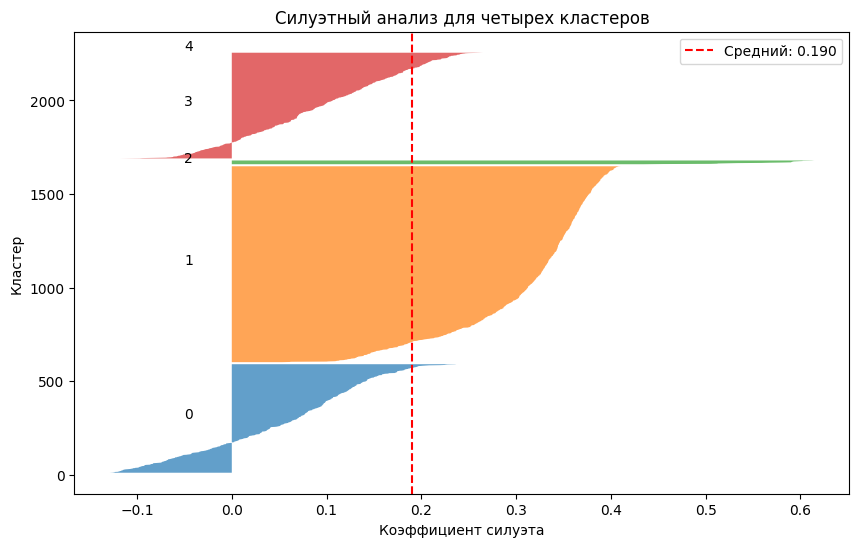

In [147]:
from sklearn.metrics import silhouette_samples, davies_bouldin_score
import matplotlib.pyplot as plt
import numpy as np

# Получить силуэтные коэффициенты для каждой точки
silhouette_vals = silhouette_samples(X_transformed, cluster_labels)

# Визуализация
plt.figure(figsize=(10, 6))
y_lower = 10
for i in range(5):
    # Сортировка значений силуэта для i-го кластера
    ith_cluster_silhouette_vals = silhouette_vals[cluster_labels == i]
    ith_cluster_silhouette_vals.sort()
    
    size_cluster_i = ith_cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    
    plt.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_vals,
                      alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.axvline(x=np.mean(silhouette_vals), color="red", linestyle="--", 
            label=f'Средний: {np.mean(silhouette_vals):.3f}')
plt.title(f'Силуэтный анализ для четырех кластеров')
plt.xlabel('Коэффициент силуэта')
plt.ylabel('Кластер')
plt.legend()
plt.show()

In [173]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=4.0, min_samples=10)
labels = dbscan.fit_predict(X_transformed)

In [174]:
silhouette_avg = silhouette_score(X_transformed, labels)
print(f"Средний коэффициент силуэта: {silhouette_avg:.3f}")

Средний коэффициент силуэта: 0.368


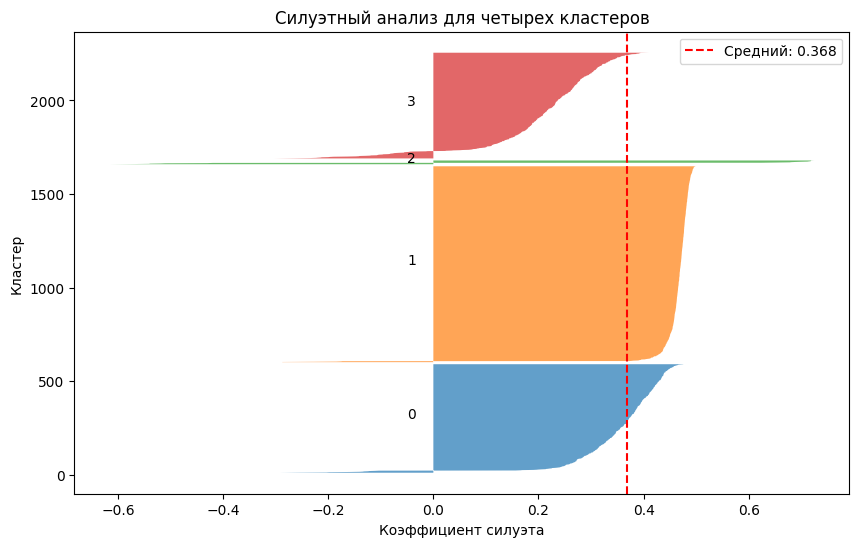

In [175]:
# Получить силуэтные коэффициенты для каждой точки
silhouette_vals = silhouette_samples(X_transformed, labels)

# Визуализация
plt.figure(figsize=(10, 6))
y_lower = 10
for i in range(4):
    # Сортировка значений силуэта для i-го кластера
    ith_cluster_silhouette_vals = silhouette_vals[cluster_labels == i]
    ith_cluster_silhouette_vals.sort()
    
    size_cluster_i = ith_cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    
    plt.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_vals,
                      alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.axvline(x=np.mean(silhouette_vals), color="red", linestyle="--", 
            label=f'Средний: {np.mean(silhouette_vals):.3f}')
plt.title(f'Силуэтный анализ для четырех кластеров')
plt.xlabel('Коэффициент силуэта')
plt.ylabel('Кластер')
plt.legend()
plt.show()

---------

In [177]:
df.shape

(2216, 29)

+ метод PCA, TSN - для уменьшения данных
+ построить визуализацию на 2D графике или 3D
+ после графика усреднить пару фич и проанализировать ДИФФ между кластерами (столбец КЛАСТЕР и groupby по фиче)
+ похожи ли объекты в рамках кластера (подгруппы кластеров и распределения - EDA)

-----
+ HDBSCAN 
+ ирер.агломерат
+ Davi-Bold metric


--------

+ если данных больше что делать? По модельке и метрикам

 - регуляризация на деревьях особенности 
 - переобучение на градиентном бустинге